# 1. Setup

In this section, we import the libraries that will be used throughout the project
and load the **Global Air Pollution Dataset** from the `data/raw` folder.

The folder structure of the project:

- `data/raw/global air pollution dataset.csv`: original CSV file downloaded from Kaggle  


We will use:

- `pandas`, `numpy` for data wrangling
- `matplotlib`, `seaborn` for basic visualisation


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

PROJECT_ROOT = os.path.abspath(os.path.join(".."))
RAW_DATA_PATH = os.path.join(PROJECT_ROOT, "data", "raw", "global air pollution dataset.csv")
df = pd.read_csv(RAW_DATA_PATH)
print("Data shape:", df.shape)
df.head()

Data shape: (23463, 12)


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


# 2. Data collection

Trong phần này, chúng ta mô tả bộ dữ liệu theo đúng đặc tả của đồ án.

## 2.1. Dữ liệu của nói về chủ đề gì?

Bộ dữ liệu này nói về **ô nhiễm không khí và chất lượng không khí** ở các thành phố
trên toàn thế giới.  
Mỗi dòng tương ứng với tình hình chất lượng không khí ở một cặp **thành phố–quốc gia** cụ thể,
được mô tả bằng **Chỉ số Chất lượng Không khí (AQI)** tổng thể và các giá trị AQI theo từng
chất ô nhiễm chính:

- **CO** (Carbon Monoxide)
- **Ozone (O₃)**
- **NO₂** (Nitrogen Dioxide)
- **PM2.5** (bụi mịn)

Với mỗi chất ô nhiễm, bộ dữ liệu chứa cả:

- một **giá trị AQI dạng số** (ví dụ `PM2.5 AQI Value`)
- một **nhãn phân loại AQI tương ứng** (ví dụ `PM2.5 AQI Category`, như *Good*,
  *Moderate*, *Unhealthy for Sensitive Groups*, *Unhealthy*, …)

Bối cảnh thực tế là **giám sát môi trường và sức khỏe cộng đồng**: ô nhiễm không khí
tác động mạnh đến sức khỏe con người, hệ sinh thái và chất lượng sống. Chính phủ và
các tổ chức sử dụng AQI để truyền đạt mức độ an toàn hay nguy hiểm của chất lượng không khí
hiện tại đối với người dân.

---

## 2.2. Nguồn dữ liệu là gì?

- **Nền tảng:** Kaggle  
- **Tên bộ dữ liệu:** *Global Air Pollution Dataset*  
- **Tác giả:** HASIB AL MUZDADID  
- **Kaggle URL:**  
  `https://www.kaggle.com/datasets/hasibalmuzdadid/global-air-pollution-dataset`
- **Định dạng tệp:** 1 tệp CSV (`global air pollution dataset.csv`)
- **Kích thước:**  23,463 dòng và 12 cột.  
  Điều này đáp ứng yêu cầu của đồ án là có ít nhất 1,000 dòng và 10 cột.

Theo mô tả công khai, bộ dữ liệu:

> “Contains AQI values of different pollutants for many cities all over the world.”

---

## 2.3. Dữ liệu này có được cấp phép sử dụng không?

Trên Kaggle, bộ dữ liệu được công bố với loại giấy phép:

- **License:** *Other (specified in description)*

Điều đó có nghĩa là:

- Bộ dữ liệu có thể được tải công khai từ Kaggle và được sử dụng rộng rãi trong bối cảnh
  giáo dục và nghiên cứu.
- Tuy nhiên, tác giả quy định các điều khoản cấp phép cụ thể trong phần mô tả bộ dữ liệu.  
  Chúng ta cần:
  - đọc và tuân thủ các điều kiện được nêu ở đó (ví dụ yêu cầu trích dẫn,
    chỉ sử dụng phi thương mại, v.v.);
  - **trích dẫn đầy đủ bộ dữ liệu Kaggle và tác giả** trong báo cáo, notebook,
    và README.

Đối với đồ án môn học này, việc sử dụng của nhóm là **mục đích giáo dục**,
phù hợp với các trường hợp sử dụng phổ biến trên Kaggle. Nhóm sẽ đưa đầy đủ
thông tin ghi công trong README và báo cáo.

---

## 2.4. Dữ liệu này được thu thập như thế nào?

Trang Kaggle không cung cấp một phần phương pháp luận quá chi tiết, nhưng từ mô tả
có thể suy ra bức tranh tổng quan sau:

- **Phương pháp thu thập:**  
  Dữ liệu tổng hợp các phép đo chất lượng không khí (AQI tổng và AQI theo từng chất ô nhiễm)
  từ nhiều nguồn giám sát ở các thành phố trên toàn cầu. Các nguồn này thường là
  các mạng lưới quan trắc môi trường sử dụng **cảm biến** và trạm đo địa phương.

- **Đối tượng mục tiêu:**  
  Các thành phố trên thế giới nơi chất lượng không khí có thể được đo hoặc ước lượng. Bộ dữ liệu
  bao gồm các thành phố thuộc nhiều quốc gia như *Russian Federation, Brazil, Italy,
  Poland, France, the United States of America, Germany, Belgium, Egypt, China, India,
  Pakistan*, v.v. (như quan sát được ở các dòng đầu của CSV).

- **Giai đoạn thời gian:**  
  Tệp CSV không có cột ngày/giờ rõ ràng, và mô tả trên Kaggle cũng không nêu cụ thể năm
  hay khoảng thời gian. Vì vậy, chúng ta xem bộ dữ liệu này như một **ảnh chụp cắt ngang**
  về tình hình chất lượng không khí ở nhiều thành phố, không phải chuỗi thời gian.  
  (Nếu sau này tìm được thông tin thời gian chi tiết hơn từ nguồn gốc ban đầu, chúng ta sẽ
  cập nhật mô tả này.)

- **Hạn chế đã biết và các thiên lệch tiềm ẩn:**
  - Mức độ bao phủ có thể **không đồng đều giữa các quốc gia và khu vực** – một số nơi có nhiều
    thành phố được ghi nhận, trong khi các nơi khác bị thiếu hoặc ít được đại diện.
  - Bộ dữ liệu tập trung vào các thành phố có hệ thống quan trắc, nên khu vực nông thôn hoặc
    vùng xa có khả năng bị thiếu đại diện.
  - Vì không có ngày đo cụ thể, chúng ta **không thể phân tích xu hướng theo thời gian**
    (ví dụ AQI thay đổi theo từng năm) chỉ dựa trên tệp CSV này.
  - Một số thành phố có thể có giá trị AQI được ước lượng từ mô hình thay vì đo trực tiếp,
    tùy theo nguồn dữ liệu ban đầu (không được mô tả đầy đủ).

Các hạn chế này sẽ được cân nhắc khi diễn giải kết quả.

---

## 2.5. Vì sao chọn bộ dữ liệu này?

Nhóm chọn *Global Air Pollution Dataset* vì các lý do sau:

1. **Tính liên quan và tác động**

   Ô nhiễm không khí là một vấn đề toàn cầu nghiêm trọng, ảnh hưởng đến:
   - sức khỏe cộng đồng (các bệnh hô hấp và tim mạch),
   - chất lượng môi trường,
   - quy hoạch đô thị và quyết định chính sách.

   Phân tích dữ liệu chất lượng không khí có thể tạo ra các kết quả có ý nghĩa
   cho người dân, nhà hoạch định chính sách và giới nghiên cứu.

2. **Cấu trúc dữ liệu phong phú для phân tích**

   Bộ dữ liệu chứa:
   - kết hợp giữa **biến phân loại** (`Country`, `City`, các nhãn AQI)  
   - và **biến số** (AQI tổng và AQI theo từng chất ô nhiễm)

   Phù hợp cho:
   - khám phá dữ liệu (phân phối, tương quan),
   - so sánh giữa các thành phố/quốc gia,
   - **bài toán học máy** (ví dụ dự đoán nhãn AQI từ các giá trị chất ô nhiễm).

3. **Kích thước và độ phức tạp**

   Với hơn 20,000 dòng và 12 cột, bộ dữ liệu:
   - **đủ lớn** để huấn luyện và đánh giá mô hình học máy,
   - nhưng vẫn **vừa sức** cho phạm vi một đồ án môn học (về bộ nhớ và thời gian chạy).

4. **Câu hỏi nghiên cứu tiềm năng**

   Bộ dữ liệu này hỗ trợ tự nhiên nhiều câu hỏi thú vị, ví dụ:
   - Thành phố hay quốc gia nào có chất lượng không khí tệ nhất?
   - Các chất ô nhiễm cụ thể (ví dụ PM2.5, NO₂, Ozone) ảnh hưởng mạnh đến AQI tổng
     đến mức nào?
   - Có thể **dự đoán AQI Category** (Good / Moderate / Unhealthy, …) từ các giá trị
     chất ô nhiễm bằng mô hình phân loại không?
   - Có sự khác biệt mang tính hệ thống về chất lượng không khí giữa các khu vực không?

   Các câu hỏi này phù hợp với yêu cầu của đồ án:
   - 2 × *n* câu hỏi có ý nghĩa,
   - ít nhất **một câu hỏi học máy**.

5. **Giá trị học tập**

   Sự kết hợp giữa bối cảnh môi trường + dữ liệu số/phân loại có cấu trúc khiến
   bộ dữ liệu này phù hợp để rèn luyện:

   - làm sạch và tiền xử lý dữ liệu,
   - khám phá dữ liệu và trực quan hóa,
   - phân tích tương quan,
   - xây dựng và đánh giá mô hình học máy.

---

**Tóm tắt phần này**

- Nhóm đã xác định chủ đề của bộ dữ liệu (ô nhiễm không khí toàn cầu và AQI).  
- Nhóm ghi lại nguồn Kaggle, tác giả, kích thước chính xác (23,463 dòng, 12 cột)
  và loại giấy phép.  
- Nhóm mô tả cách dữ liệu có thể đã được thu thập và nêu các hạn chế chính
  (thiên lệch bao phủ, thiếu thông tin thời gian).  
- Nhóm giải thích vì sao bộ dữ liệu này liên quan và phù hợp cho đồ án nhóm.

Trong phần tiếp theo (**3. Khám phá dữ liệu**), chúng ta sẽ khảo sát có hệ thống
cấu trúc và chất lượng của bộ dữ liệu (số dòng/cột, kiểu dữ liệu, phân phối,
giá trị thiếu, tương quan và các nhận định ban đầu).


# 3. Data Exploration

Trong phần này, chúng ta sẽ bám theo đặc tả của đồ án (Mục 2.2 – Data Exploration)
để khảo sát kỹ cấu trúc, tính toàn vẹn và các đặc điểm cơ bản của
Global Air Pollution Dataset.

Chúng ta sẽ lần lượt đi qua:

- **3.1 Tổng quan bộ dữ liệu - Thông tin cơ bản**
- **3.2 Tính toàn vẹn dữ liệu (trùng lặp, dòng trống)**
- **3.3 Danh sách cột & Kiểu dữ liệu**

Mục tiêu là hiểu mỗi dòng và mỗi cột đại diện cho điều gì, kiểm tra xem dữ liệu
có ổn định về mặt cấu trúc hay không, và chuẩn bị một bức tranh rõ ràng về những
biến nào sẽ hữu ích cho phân tích và mô hình hóa ở các phần sau.


## 3.1 Tổng quan về bộ dữ liệu – Thông tin cơ bản

In [3]:
print("(Hàng, Cột):", df.shape)

print("\nThông tin cơ bản (df.info()):")
df.info()

print("\nXem trước 5 hàng đầu tiên:")
df.head()

(Hàng, Cột): (23463, 12)

Thông tin cơ bản (df.info()):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23036 non-null  object
 1   City                23462 non-null  object
 2   AQI Value           23463 non-null  int64 
 3   AQI Category        23463 non-null  object
 4   CO AQI Value        23463 non-null  int64 
 5   CO AQI Category     23463 non-null  object
 6   Ozone AQI Value     23463 non-null  int64 
 7   Ozone AQI Category  23463 non-null  object
 8   NO2 AQI Value       23463 non-null  int64 
 9   NO2 AQI Category    23463 non-null  object
 10  PM2.5 AQI Value     23463 non-null  int64 
 11  PM2.5 AQI Category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB

Xem trước 5 hàng đầu tiên:


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


Từ kết quả `df.shape` và `df.info()` ở trên, có thể quan sát được rằng:
- Bộ dữ liệu chứa **23.463 dòng** và **12 cột**.
- Mỗi **dòng** biểu diễn tình trạng chất lượng không khí cho một cặp **thành phố–quốc gia** cụ thể, được mô tả bởi:
  - một **AQI Value** và **AQI Category** tổng thể, và  
  - các giá trị AQI và phân loại AQI theo từng chất ô nhiễm riêng lẻ cho CO, Ozone, NO₂ và PM2.5.

Nói cách khác, bộ dữ liệu này là một **ảnh chụp cắt ngang (cross-sectional snapshot)** về mức độ ô nhiễm không khí trên nhiều thành phố trên thế giới, chứ không phải là chuỗi thời gian theo từng thành phố.

Về mặt “quy mô”, bộ dữ liệu (số lượng bản ghi và số lượng cột) là đủ để:

- Thực hiện thống kê mô tả và trực quan hóa,
- Phân tích so sánh giữa các thành phố/quốc gia, và
- Xây dựng các mô hình học máy trong những giai đoạn tiếp theo.

## 3.2 Tính toàn vẹn dữ liệu (trùng lặp, dòng trống)

In [4]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicated rows: {num_duplicates}")

if num_duplicates > 0:
    print("\nExample of duplicated rows:")
    print(df[df.duplicated()].head())

num_fully_empty_rows = df.isna().all(axis=1).sum()
print(f"\nNumber of fully empty rows (all values NaN): {num_fully_empty_rows}")

Number of duplicated rows: 0

Number of fully empty rows (all values NaN): 0


Để đánh giá tính toàn vẹn dữ liệu cơ bản, ta kiểm tra hai khía cạnh:

1. **Các dòng trùng lặp hoàn toàn (exact duplicate rows)**  
2. **Các dòng hoàn toàn trống (fully empty rows – những dòng mà mọi cột đều bị thiếu)**

Từ kết quả của ô code ở trên:

- Bộ dữ liệu có **0 dòng trùng lặp**  (tức là không có dòng nào giống hệt nhau trên tất cả các cột).  
  - Do đó, ở giai đoạn này **không cần** loại bỏ dòng trùng lặp nào.

- Số lượng **dòng hoàn toàn trống** (tất cả giá trị đều là `NaN`) là **0**.  
  - Điều này có nghĩa là không có dòng nào bị thiếu toàn bộ thông tin,
    nên chưa cần thao tác dọn dẹp cấu trúc nào ở đây.

Ở giai đoạn khám phá dữ liệu, ta chỉ **quan sát và ghi nhận** các vấn đề toàn vẹn này.  
Việc loại bỏ các dòng trùng lặp hoặc dòng trống (nếu cần) sẽ được thực hiện rõ ràng trong  
**giai đoạn tiền xử lý (preprocessing)** cho từng bài toán hoặc mục tiêu phân tích cụ thể.

## 3.3 Danh sách cột & Kiểu dữ liệu

In [5]:
print("Data types of all columns:\n")
print(df.dtypes)

column_descriptions = {
    "Country": "Country where the city is located",
    "City": "City name",
    "AQI Value": "Overall Air Quality Index (numeric)",
    "AQI Category": "Overall AQI category (Good, Moderate, etc.)",
    "CO AQI Value": "AQI value contributed by CO (Carbon Monoxide)",
    "CO AQI Category": "AQI category for CO",
    "Ozone AQI Value": "AQI value contributed by Ozone (O₃)",
    "Ozone AQI Category": "AQI category for Ozone",
    "NO2 AQI Value": "AQI value contributed by NO₂ (Nitrogen Dioxide)",
    "NO2 AQI Category": "AQI category for NO₂",
    "PM2.5 AQI Value": "AQI value contributed by PM2.5 (fine particulate matter)",
    "PM2.5 AQI Category": "AQI category for PM2.5",
}

summary_rows = []
for col in df.columns:
    summary_rows.append({
        "column_name": col,
        "dtype": df[col].dtype,
        "description": column_descriptions.get(col, "(to be defined)"),
    })

column_summary = pd.DataFrame(summary_rows)
column_summary


Data types of all columns:

Country               object
City                  object
AQI Value              int64
AQI Category          object
CO AQI Value           int64
CO AQI Category       object
Ozone AQI Value        int64
Ozone AQI Category    object
NO2 AQI Value          int64
NO2 AQI Category      object
PM2.5 AQI Value        int64
PM2.5 AQI Category    object
dtype: object


,column_name,dtype,description
0,Country,object,Country where the city is located
1,City,object,City name
2,AQI Value,int64,Overall Air Quality Index (numeric)
3,AQI Category,object,"Overall AQI category (Good, Moderate, etc.)"
4,CO AQI Value,int64,AQI value contributed by CO (Carbon Monoxide)
5,CO AQI Category,object,AQI category for CO
6,Ozone AQI Value,int64,AQI value contributed by Ozone (O₃)
7,Ozone AQI Category,object,AQI category for Ozone
8,NO2 AQI Value,int64,AQI value contributed by NO₂ (Nitrogen Dioxide)
9,NO2 AQI Category,object,AQI category for NO₂


### 3.3.1. Kiểm kê cột và ý nghĩa (Column inventory and meanings)

Dataset chứa các cột chính sau:

- **Country**  
  - Quốc gia nơi thành phố được ghi nhận.  
  - Biến phân loại, hữu ích để nhóm và so sánh chất lượng không khí giữa các quốc gia hoặc khu vực.

- **City**  
  - Tên thành phố.  
  - Biến phân loại, dùng để so sánh chất lượng không khí giữa các thành phố.

- **AQI Value**  
  - **Chỉ số Chất lượng Không khí (AQI)** tổng hợp của thành phố.  
  - Biến số dạng số (integer).  
  - Tóm tắt tác động tổng hợp của các chất ô nhiễm thành một chỉ số duy nhất.

- **AQI Category**  
  - Nhóm phân loại định tính của AQI (ví dụ *Good*, *Moderate*, *Unhealthy for Sensitive Groups*, *Unhealthy*, …).  
  - Biến phân loại.  
  - Đây là ứng viên tự nhiên cho **bài toán phân loại (classification)** trong machine learning.

- **CO AQI Value**  
  - Giá trị AQI do **Carbon Monoxide (CO)** đóng góp.  
  - Biến số dạng số.  
  - Có thể dùng làm feature giải thích cho AQI tổng hoặc phân tích ô nhiễm theo chất.

- **CO AQI Category**  
  - Nhóm phân loại tương ứng với CO AQI Value (ví dụ *Good*, *Moderate*).  
  - Biến phân loại.

- **Ozone AQI Value**  
  - AQI do **Ozone (O₃)** đóng góp.  
  - Biến số dạng số.

- **Ozone AQI Category**  
  - Nhóm phân loại tương ứng với Ozone AQI Value.  
  - Biến phân loại.

- **NO2 AQI Value**  
  - AQI do **Nitrogen Dioxide (NO₂)** đóng góp.  
  - Biến số dạng số.

- **NO2 AQI Category**  
  - Nhóm phân loại tương ứng với NO₂ AQI Value.  
  - Biến phân loại.

- **PM2.5 AQI Value**  
  - AQI do **PM2.5** (bụi mịn ≤ 2.5 µm) đóng góp.  
  - Biến số dạng số.  
  - Thường liên quan mạnh tới rủi ro sức khỏe và chất lượng không khí tổng thể.

- **PM2.5 AQI Category**  
  - Nhóm phân loại tương ứng với PM2.5 AQI Value.  
  - Biến phân loại.

Tóm lại:

- **Hữu ích cho phân tích & ML (feature):**
  - Các giá trị AQI theo từng chất ô nhiễm:  
    - `CO AQI Value`, `Ozone AQI Value`, `NO2 AQI Value`, `PM2.5 AQI Value`
  - Các biến phân loại bối cảnh:
    - `Country`, `City`

- **Các biến mục tiêu (label) tiềm năng cho ML:**
  - `AQI Category` (phân loại chất lượng không khí tổng)
  - Có thể thêm các category theo chất ô nhiễm nếu xây mô hình chuyên biệt.

Dataset **không** có cột ID kỹ thuật dư thừa cần loại bỏ ở giai đoạn này.  
Tất cả các cột đều có ý nghĩa cho phân tích hoặc mô hình hóa.

---

### 3.3.2. Kiểu dữ liệu và khả năng chuyển đổi (Data types and potential conversions)

Dựa trên kết quả `df.dtypes`:

- Các cột số liên quan đến AQI được lưu dưới dạng **số nguyên** (`int64`), phù hợp với bản chất chỉ số AQI.
- Các cột dạng văn bản (`Country`, `City`, các cột `* Category`) được lưu dưới dtype **object**, đại diện cho dữ liệu chuỗi / phân loại.

Trong **giai đoạn khám phá dữ liệu (EDA)**, các kiểu dữ liệu này là phù hợp.

Ở các giai đoạn sau (ví dụ mô hình hóa), có thể cần:

- Chuyển các cột phân loại (`Country`, `City`, `AQI Category`, các pollutant categories) sang **categorical dtype** hoặc mã hóa (one-hot encoding, target encoding) khi đưa vào mô hình ML.
- Chuẩn hóa hoặc scale các giá trị AQI nếu mô hình yêu cầu (đặc biệt là các mô hình dựa trên khoảng cách hoặc gradient).

Ở thời điểm này, **không có yêu cầu bắt buộc phải chuyển đổi kiểu dữ liệu** để tiếp tục EDA,  
nhưng ta đã có cái nhìn rõ ràng về vai trò và kiểu của từng cột cho các bước về sau.


## 3.4 Phân tích các cột số

#### 3.4.1. Thống kê mô tả

In [6]:
num_cols = [
    "AQI Value",
    "CO AQI Value",
    "Ozone AQI Value",
    "NO2 AQI Value",
    "PM2.5 AQI Value",
]

num_cols = [col for col in num_cols if col in df.columns]
num_desc = df[num_cols].describe().T
num_desc

,count,mean,std,min,25%,50%,75%,max
AQI Value,23463.0,72.010868,56.055220,6.0,39.0,55.0,79.0,500.0
CO AQI Value,23463.0,1.368367,1.832064,0.0,1.0,1.0,1.0,133.0
Ozone AQI Value,23463.0,35.193709,28.098723,0.0,21.0,31.0,40.0,235.0
NO2 AQI Value,23463.0,3.063334,5.254108,0.0,0.0,1.0,4.0,91.0
PM2.5 AQI Value,23463.0,68.519755,54.796443,0.0,35.0,54.0,79.0,500.0


Từ bảng mô tả:
- **AQI Value**
  - Mean ≈ **72.0**, median = **55**, std ≈ **56.1**
  - Min = **6**, max = **500**
- **CO AQI Value**
  - Mean ≈ **1.37**, median = **1**, std ≈ **1.83**
  - Min = **0**, max = **133**
- **Ozone AQI Value**
  - Mean ≈ **35.2**, median = **31**, std ≈ **28.1**
  - Min = **0**, max = **235**
- **NO2 AQI Value**
  - Mean ≈ **3.06**, median = **1**, std ≈ **5.25**
  - Min = **0**, max = **91**
- **PM2.5 AQI Value**
  - Mean ≈ **68.5**, median = **54**, std ≈ **54.8**
  - Min = **0**, max = **500**

Về tính hợp lệ của giá trị min/max:

- Giá trị min 0 trong AQI theo chất ô nhiễm có thể có trong thang đo AQI, phản ánh điều kiện rất sạch hoặc mức rất thấp; không quan sát thấy giá trị âm hoặc mã giữ chỗ bất thường.

- Giá trị max = 500 đối với Giá trị AQI và Giá trị AQI PM2.5 trùng với giới hạn trên của thang đo AQI tiêu chuẩn, do đó có thể được coi là các trường hợp ô nhiễm cực đoan hợp lệ, không nhất thiết là lỗi nhập dữ liệu.

### Để hỗ trợ thảo luận sau về các giá trị cực đoan, ta cung cấp một bản tóm tắt sơ bộ về giá trị ngoại lai sử dụng quy tắc IQR.

In [7]:
def count_outliers_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return mask.sum(), mask.mean() * 100, lower, upper

rows = []
for col in num_cols:
    s = df[col].dropna()
    cnt, pct, lower, upper = count_outliers_iqr(s)
    rows.append({
        "column": col,
        "outlier_count": int(cnt),
        "outlier_percent": round(pct, 2),
        "lower_bound": round(lower, 2),
        "upper_bound": round(upper, 2),
    })

outlier_summary = pd.DataFrame(rows).sort_values("outlier_count", ascending=False)
outlier_summary

,column,outlier_count,outlier_percent,lower_bound,upper_bound
1,CO AQI Value,8596,36.64,1.0,1.0
0,AQI Value,2935,12.51,-21.0,139.0
4,PM2.5 AQI Value,2641,11.26,-31.0,145.0
3,NO2 AQI Value,1681,7.16,-6.0,10.0
2,Ozone AQI Value,1513,6.45,-7.5,68.5


**Lưu ý về cách diễn giải các giá trị ngoại lệ IQR:**

Đối với **Giá trị AQI CO**, các phân vị thứ 25, 50 và 75 đều bằng 1, cho kết quả **IQR = 0**.
Điều này tạo ra **giới hạn dưới = giới hạn trên = 1.0**, do đó bất kỳ giá trị nào ≠ 1 đều được đánh dấu là giá trị ngoại lệ.

Do đó, tỷ lệ ngoại lệ cao đối với CO chủ yếu phản ánh **một phân phối rất rời rạc và tập trung**, không nhất thiết là dữ liệu bất thường hoặc sai lệch.

Đối với **Giá trị AQI** và **Giá trị AQI PM2.5**, các giới hạn trên dựa trên IQR khoảng ~140–145 cho thấy
một phần đáng chú ý của các đợt ô nhiễm cao, phù hợp với giới hạn của thang đo AQI là 500.

#### 3.4.2. Tóm tắt các cột bị thiếu

In [8]:
num_missing_count = df[num_cols].isna().sum()
num_missing_percent = df[num_cols].isna().mean() * 100

num_missing_summary = pd.DataFrame({
    "missing_count": num_missing_count,
    "missing_percent": num_missing_percent.round(2)
})
num_missing_summary

,missing_count,missing_percent
AQI Value,0,0.0
CO AQI Value,0,0.0
Ozone AQI Value,0,0.0
NO2 AQI Value,0,0.0
PM2.5 AQI Value,0,0.0


> Tất cả các cột số đều có 0 giá trị bị thiếu (0,0%).
→ Dữ liệu số rất đầy đủ, không cần phải suy diễn trong bước EDA; trọng tâm xử lý trước nên chuyển sang xử lý độ lệch phân phối và các giá trị cực trị.

#### 3.4.3. Phân phối và xu hướng tập trung

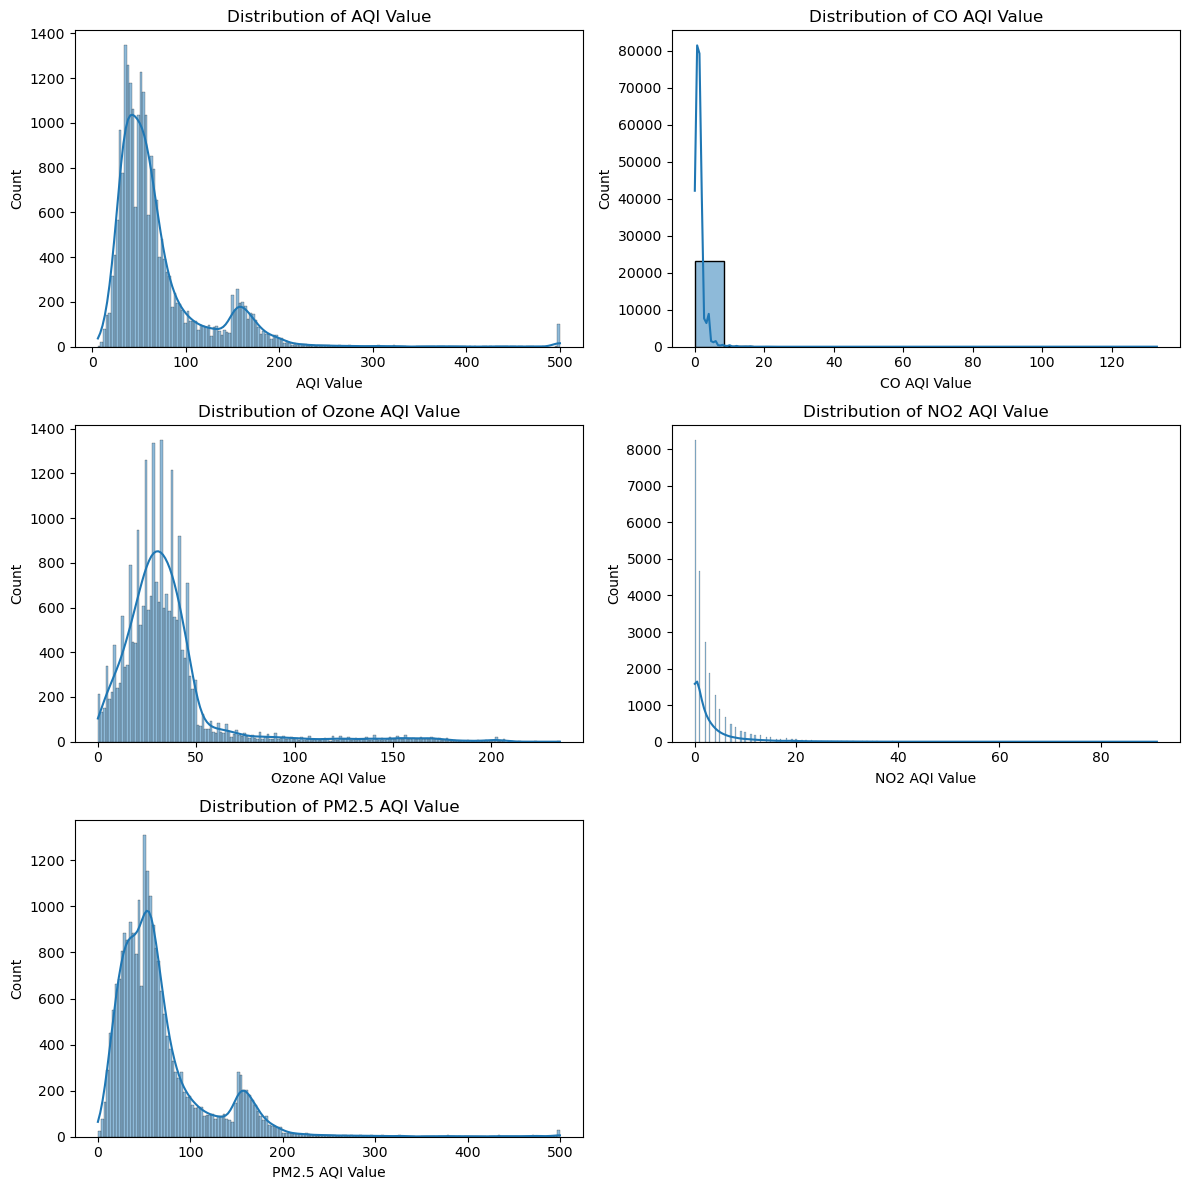

In [9]:
hist_cols = [
    "AQI Value",
    "CO AQI Value",
    "Ozone AQI Value",
    "NO2 AQI Value",
    "PM2.5 AQI Value",
]

hist_cols = [c for c in hist_cols if c in df.columns]

n = len(hist_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(hist_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**AQI Value**:
  - Phần lớn quan sát nằm xấp xỉ trong khoảng **[30, 100]**, với một đỉnh rõ rệt
    quanh **40–80**.
  - Có thể thấy một “gợn” thứ hai quanh **150–180** và một số lượng rất nhỏ
    giá trị cực trị gần **500**.
  - Phân phối **lệch phải rất mạnh**: nhiều thành phố có AQI tương đối thấp hoặc
    trung bình, trong khi một nhóm nhỏ thể hiện chất lượng không khí rất kém.
    
**CO AQI Value**:
  - Khối lượng chính của phân phối tập trung ở **0–3**, với median = **1**.
  - Một vài quan sát đạt đến các giá trị cao hơn nhiều (tối đa **133**), nhưng những trường hợp này hiếm.
  - Đây là một phân phối **lệch phải mạnh** bị chi phối bởi mức ô nhiễm CO thấp
    và một vài sự kiện cực đoan.
    
**Ozone AQI Value**:
  - Giá trị chủ yếu trong khoảng **[10, 60]**, với đỉnh quanh **30–40**.
  - Có một đuôi phải kéo dài vượt **100** và lên tới **235**.
  - So với CO và NO₂, phân phối này trải rộng hơn đôi chút nhưng vẫn
    rõ ràng là **lệch phải**.
    
**NO2 AQI Value**:
  - Phần lớn bản ghi nằm giữa **0 và 5**, với median = **1** và
    phân vị 75% ở **4**.
  - Có một đuôi phải dài với một số giá trị cao hơn không thường xuyên (tối đa **91**).
  - Điều này cho thấy **đa số thành phố có NO₂ AQI thấp**, trong khi một vài thành phố
    trải qua mức ô nhiễm NO₂ cao hơn nhiều.
    
**PM2.5 AQI Value**:
  - Mẫu hình rất giống với AQI tổng thể: đa số quan sát nằm xấp xỉ trong
    **[30, 100]**, với mật độ lớn quanh **40–80**.
  - Xuất hiện một “gợn” thứ hai quanh **150–180**, và có các giá trị cực trị lên tới
    **500**.
  - Phân phối **lệch phải mạnh**, gợi ý rằng các đợt PM2.5 cao
    có xảy ra nhưng ít thường xuyên hơn nhiều so với các mức trung bình.
    
> ### Nhìn chung, tất cả các biến số đều có **đuôi phải dài**. Điều này phù hợp với nhận định rằng ô nhiễm mức trung bình là phổ biến, trong khi ô nhiễm rất nặng là hiếm nhưng vẫn có thể xảy ra.

#### 3.4.4. Range & outliers (boxplots)

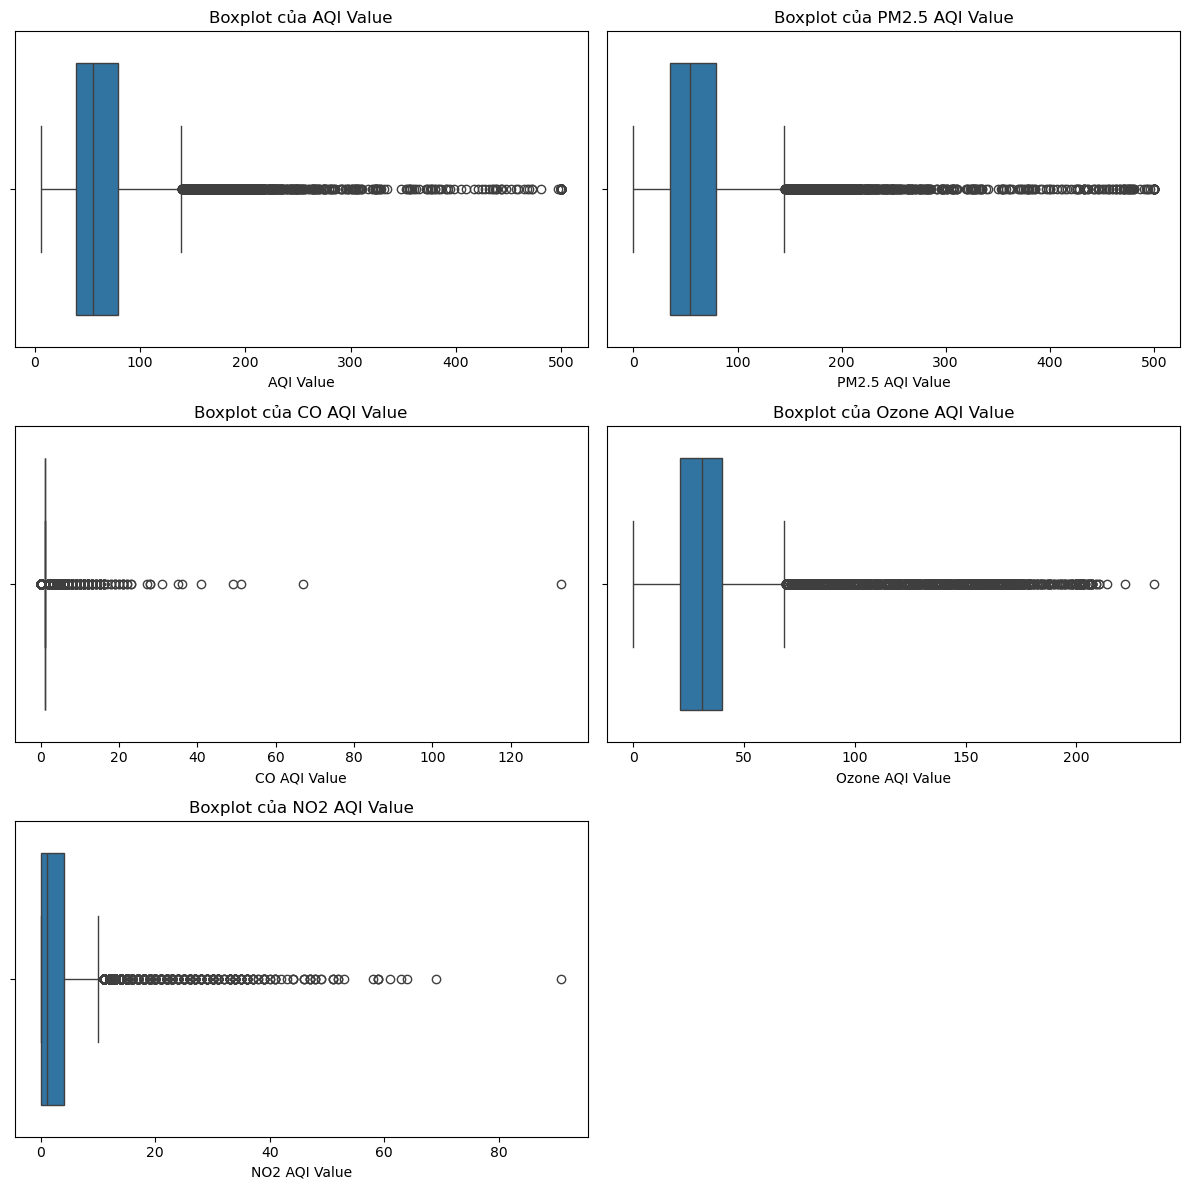

In [10]:
box_cols = [
    "AQI Value",
    "PM2.5 AQI Value",
    "CO AQI Value",
    "Ozone AQI Value",
    "NO2 AQI Value",
]

# keep only existing columns
box_cols = [c for c in box_cols if c in df.columns]

n = len(box_cols)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(box_cols):
    sns.boxplot(x=df[col].dropna(), ax=axes[i])
    axes[i].set_title(f"Boxplot của {col}")
    axes[i].set_xlabel(col)

# remove empty subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- Với **AQI Value** và **PM2.5 AQI Value**, phần lớn dữ liệu (IQR) nằm dưới khoảng
  **100**, nhưng có nhiều điểm vượt quá râu trên, kéo dài
  đến giá trị tối đa **500**.
- Với **CO AQI Value**, gần như tất cả quan sát tập trung trong khoảng
  **0–3**, trong khi các ngoại lệ xuất hiện quanh **10–40**, với một vài trường hợp cực đoan
  đạt xấp xỉ **60** và **133**.
- Với **Ozone AQI Value**, phần lớn giá trị nằm dưới **60**, nhưng có một đuôi dài các
  ngoại lệ từ khoảng **60** lên tới trên **200**.
- Với **NO2 AQI Value**, hộp chủ yếu nằm dưới **10**, trong khi một nhóm nhỏ
  bản ghi có giá trị cao hơn nhiều, khoảng **30–90**.
  
> Các giá trị cao tới **500** cho AQI và PM2.5 vẫn nằm trong giới hạn trên của thang AQI chuẩn, nên có thể hiểu là **các đợt ô nhiễm cực đoan hợp lý**, không nhất thiết là lỗi nhập liệu. Tuy nhiên, khi phân tích dữ liệu và xây dựng mô hình, các giá trị cực trị này nên được xử lý cẩn trọng (ví dụ dùng thống kê bền vững hoặc các biến đổi phù hợp như log-scaling hoặc chuẩn hoá).

## 3.5 Categorical Columns Analysis

In [11]:
cat_cols = [
    "Country",
    "City",
    "AQI Category",
    "CO AQI Category",
    "Ozone AQI Category",
    "NO2 AQI Category",
    "PM2.5 AQI Category",
]

cat_cols = [col for col in cat_cols if col in df.columns]

**Kết luận:**
Chúng tôi chọn các cột phân loại chính mô tả bối cảnh địa lý (Quốc gia, Thành phố)
và nhãn chất lượng không khí (Danh mục AQI tổng thể và các danh mục cụ thể về chất ô nhiễm).
Các biến này sẽ được kiểm tra tính đầy đủ, tính trọng số và sự cân bằng của các lớp
để đánh giá khả năng sử dụng của chúng cho phân tích mô tả và mô hình hóa sau này.

In [12]:
cat_nunique = df[cat_cols].nunique()
cat_missing_count = df[cat_cols].isna().sum()
cat_missing_percent = df[cat_cols].isna().mean() * 100

cat_summary = pd.DataFrame({
    "n_distinct": cat_nunique,
    "missing_count": cat_missing_count,
    "missing_percent": cat_missing_percent.round(2),
})
cat_summary

,n_distinct,missing_count,missing_percent
Country,175,427,1.82
City,23462,1,0.00
AQI Category,6,0,0.00
CO AQI Category,3,0,0.00
Ozone AQI Category,5,0,0.00
NO2 AQI Category,2,0,0.00
PM2.5 AQI Category,6,0,0.00


**Kết luận:**
Quét nhanh tần suất này đã cho thấy ba mô hình quan trọng:
1) **Phân bố quốc gia không đồng đều**: một vài quốc gia lớn đóng góp nhiều bản ghi,
vì vậy việc so sánh ở cấp quốc gia có thể bị chi phối bởi các quốc gia có tần suất cao này.
2) **Thành phố có số lượng thành phần cực kỳ cao**: các thành phố "hàng đầu" đều xuất hiện một lần,
xác nhận Thành phố hoạt động như một mã định danh gần như duy nhất.
3) **Mất cân bằng danh mục rất lớn**, đặc biệt đối với các danh mục chất ô nhiễm:
`Danh mục AQI CO` và `Danh mục AQI NO2` gần như hoàn toàn là "Tốt",
trong khi `Danh mục AQI PM2.5` cho thấy sự biến động phong phú hơn tương tự như `Danh mục AQI` tổng thể.

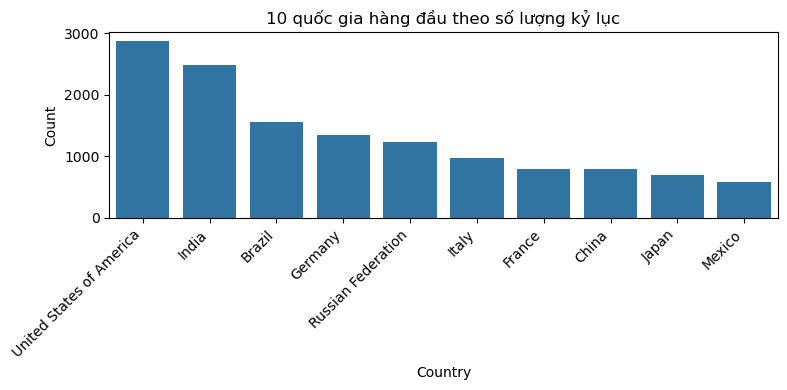

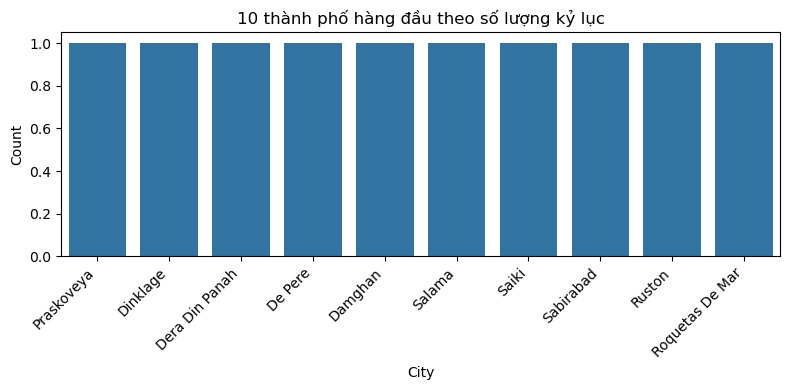

In [13]:
# Bar plots for top categories (for some key categorical columns)
# Top 10 countries
if "Country" in df.columns:
    top_countries = df["Country"].value_counts().head(10)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=top_countries.index, y=top_countries.values)
    plt.title("10 quốc gia hàng đầu theo số lượng kỷ lục")
    plt.xlabel("Country")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    
# Top 10 cities
if "City" in df.columns:
    top_cities = df["City"].value_counts().head(10)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=top_cities.index, y=top_cities.values)
    plt.title("10 thành phố hàng đầu theo số lượng kỷ lục")
    plt.xlabel("City")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

**Quốc gia**
- Biểu đồ thanh của 10 quốc gia đứng đầu cho thấy sự phân bố rất không đồng đều:
  - **United States of America**: **2,872** records  
  - **India**: **2,488**  
  - **Brazil**: **1,562**  
  - **Germany**: **1,345**  
  - **Russian Federation**: **1,241**  
  - **Italy**: **979**  
  - **France**: **802**  
  - **China**: **795**  
  - **Japan**: **702**  
  - **Mexico**: **588**

- Một số quốc gia lớn chiếm ưu thế trong tập dữ liệu, trong khi nhiều quốc gia trong số 175 quốc gia chỉ có một số lượng nhỏ hàng. Điều này có nghĩa là bất kỳ phân tích nào theo quốc gia sẽ bị ảnh hưởng mạnh mẽ bởi các quốc gia có tần suất cao này.
  
**Thành phố**
- Có **23.462 tên thành phố riêng biệt** và 10 thành phố đứng đầu trong biểu đồ thanh đều xuất hiện đúng **một lần**.
- Điều này khẳng định rằng trên thực tế, **mỗi hàng tương ứng với một bản ghi thành phố-quốc gia duy nhất**, do đó `Thành phố` hoạt động gần giống như một mã định danh.
- Vì có quá nhiều giá trị duy nhất với tần suất 1, `Thành phố` không phù hợp làm đối tượng trực tiếp cho hầu hết các mô hình không có mã hóa hoặc nhóm phức tạp.

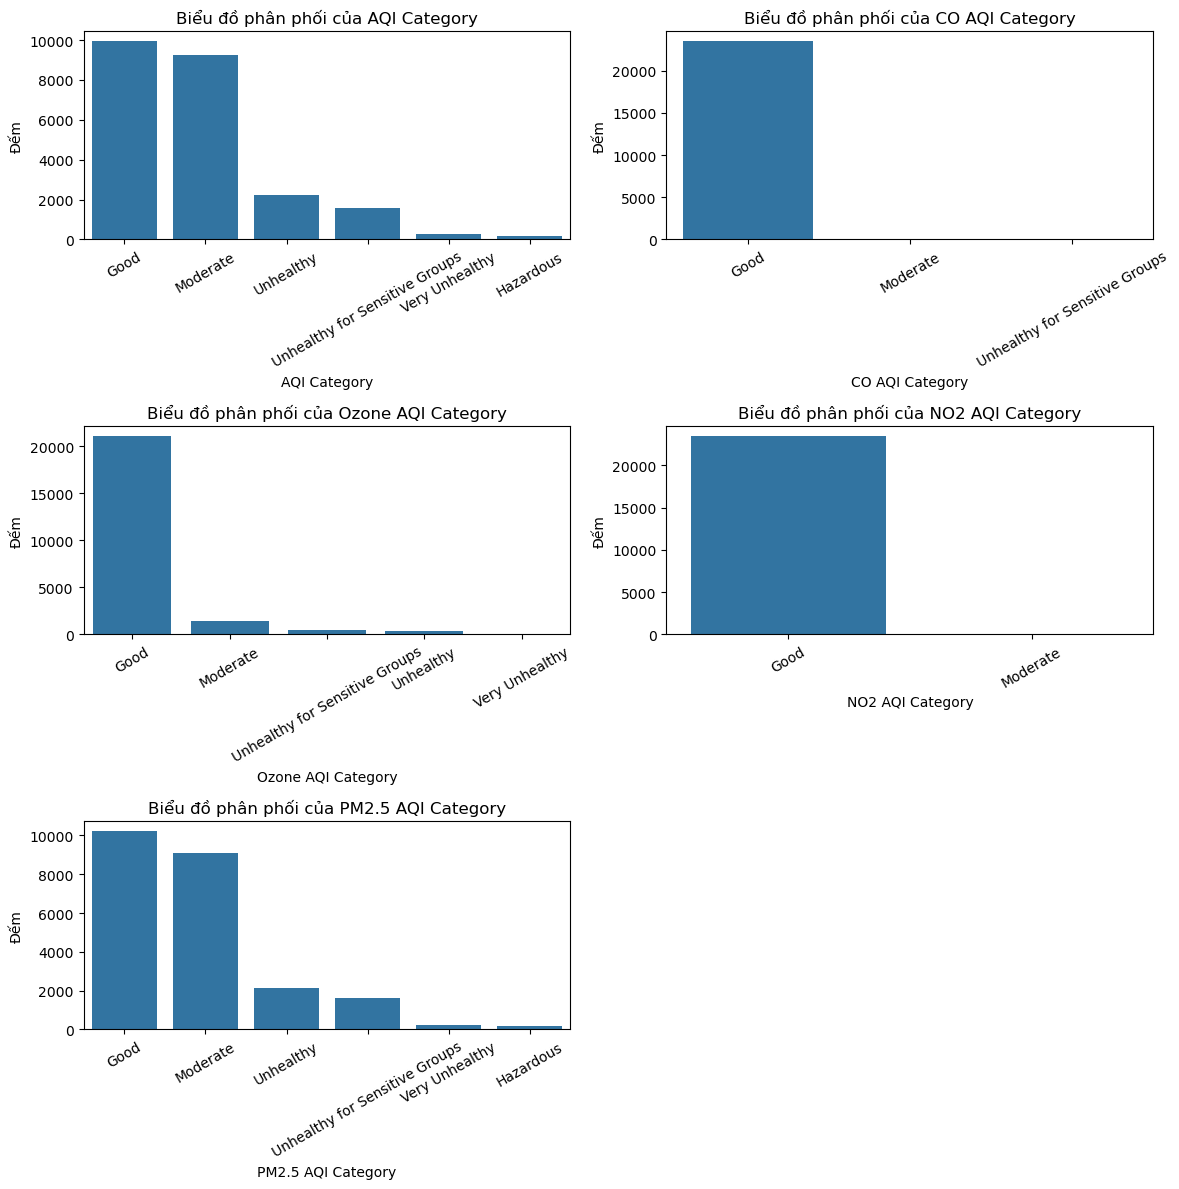

In [14]:
cat_plots = [
    "AQI Category",
    "CO AQI Category",
    "Ozone AQI Category",
    "NO2 AQI Category",
    "PM2.5 AQI Category",
]
    
n = len(cat_plots)
ncols = 2
nrows = (n + ncols - 1) // ncols  # ceil

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(cat_plots):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i])
    axes[i].set_title(f"Biểu đồ phân phối của {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Đếm")
    axes[i].tick_params(axis="x", rotation=30)

for j in range(n, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### Nhận xét hình phân phối 5 biến phân loại liên quan đến AQI

Hình trên thể hiện phân phối của 5 cột phân loại quan trọng gồm: **AQI Category, CO AQI Category, Ozone AQI Category, NO2 AQI Category, PM2.5 AQI Category**. Các biểu đồ giúp đánh giá mức độ đa dạng nhãn, sự mất cân bằng lớp và tính phù hợp của từng biến cho phân tích và mô hình hoá.

#### 1) AQI Category (overall)
Hai nhóm chiếm ưu thế là:
- **Good: 9,936**
- **Moderate: 9,231**

Các mức ô nhiễm nặng ít hơn rõ rệt:
- **Unhealthy: 2,227**
- **Unhealthy for Sensitive Groups: 1,591**
- **Very Unhealthy: 287**
- **Hazardous: 191**

Phân phối này cho thấy **mất cân bằng lớp** theo hướng nghiêng về điều kiện không khí tốt/trung bình. Về mặt mô tả, đa số thành phố nằm trong vùng AQI chấp nhận được, trong khi nhóm trường hợp cực đoan vẫn tồn tại nhưng chiếm tỷ lệ nhỏ.

Nếu sử dụng **AQI Category** làm nhãn phân loại, nên ưu tiên các thước đo đánh giá phản ánh tốt lớp hiếm (ví dụ **macro-F1**) và cân nhắc **class_weight** hoặc **resampling** để giảm ảnh hưởng của mất cân bằng.

#### 2) CO AQI Category
Gần như toàn bộ dữ liệu nằm ở:
- **Good: 23,460 / 23,463**

Chỉ có:
- **Moderate: 2**
- **Unhealthy for Sensitive Groups: 1**

Biểu đồ thể hiện mức độ lệch cực mạnh về **Good**, cho thấy biến này có **độ biến thiên rất thấp** ở dạng category. Vì vậy, CO AQI Category chủ yếu phù hợp để mô tả tổng quan, không lý tưởng để dùng làm **target** trong bài toán phân loại. Nếu dùng làm **feature**, đóng góp phân biệt giữa các mẫu cũng sẽ hạn chế.

#### 3) NO2 AQI Category
Tình hình tương tự CO:
- **Good: 23,448**
- **Moderate: 15**

Phân phối gần như đơn lớp cho thấy NO2 AQI Category chỉ hữu ích ở mức mô tả tổng quát. Trong mô hình học máy, biến này không phù hợp làm nhãn mục tiêu và cần cân nhắc kỹ nếu đưa vào như một feature phân loại độc lập.

#### 4) Ozone AQI Category
Phân phối đa dạng hơn CO/NO2:
- **Good: 21,069**
- **Moderate: 1,445**
- **Unhealthy for Sensitive Groups: 491**
- **Unhealthy: 405**
- **Very Unhealthy: 53**

Dù vẫn lệch về Good, ozone category có đủ các nhóm phụ để quan sát sự khác biệt mức rủi ro theo O₃. Về mô hình, có thể cân nhắc như một nhãn phụ hoặc feature, nhưng vẫn cần tính đến vấn đề **imbalance**.

#### 5) PM2.5 AQI Category
Đây là biến có phân phối “giàu thông tin” nhất:
- **Good: 10,208**
- **Moderate: 9,075**
- **Unhealthy: 2,129**
- **Unhealthy for Sensitive Groups: 1,624**
- **Very Unhealthy: 255**
- **Hazardous: 172**

Hình dạng phân phối rất giống với **AQI Category**, gợi ý rằng **PM2.5 có vai trò quan trọng trong việc hình thành chất lượng không khí tổng thể**. Biến này phù hợp cho phân tích phân tầng và có tiềm năng hỗ trợ tốt cho các mô hình dự đoán liên quan đến AQI.

Khi xây dựng mô hình, cần lưu ý nguy cơ **target leakage** nếu dự đoán **AQI Category** bằng các biến vốn có quan hệ cấu thành trực tiếp với nhãn.

---

### Kết luận
- **AQI Category** và **PM2.5 AQI Category** có phân phối nhiều lớp, phản ánh rõ mức độ ô nhiễm theo thang chuẩn; phù hợp cho phân tích mô tả và có thể dùng cho ML khi đi kèm chiến lược xử lý mất cân bằng.
- **CO AQI Category** và **NO2 AQI Category** gần như chỉ có một lớp “Good”, nên giá trị phân biệt thấp và không phù hợp làm nhãn mục tiêu.
- **Ozone AQI Category** nằm ở mức trung gian: vẫn lệch về Good nhưng đủ biến thiên để quan sát xu hướng và cân nhắc sử dụng có chọn lọc trong mô hình.

## 3.6 Phân tích dữ liệu thiếu (Missing Data Analysis)
### 3.6.1 Tóm tắt mức độ thiếu tổng quan

In [15]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_percent"] = (missing["missing_count"] / len(df) * 100).round(2)
missing_sorted = missing.sort_values("missing_percent", ascending=False)
missing_sorted

,missing_count,missing_percent
Country,427,1.82
City,1,0.00
AQI Value,0,0.00
AQI Category,0,0.00
CO AQI Value,0,0.00
CO AQI Category,0,0.00
Ozone AQI Value,0,0.00
Ozone AQI Category,0,0.00
NO2 AQI Value,0,0.00
NO2 AQI Category,0,0.00


Bảng tóm tắt giá trị thiếu cho thấy bộ dữ liệu có mức độ đầy đủ rất cao.

- **Country** là cột duy nhất có tỷ lệ thiếu đáng kể:
  - **427 dòng bị thiếu (1.82%)**.
- **City** chỉ có **1 dòng bị thiếu**, mức này không đáng kể.
- Tất cả các cột số và cột nhãn liên quan đến AQI còn lại đều có **0 giá trị thiếu**.

Điều này cho thấy giá trị thiếu chỉ tập trung ở **thông tin bối cảnh địa lý**, trong khi các phép đo chất lượng không khí cốt lõi vẫn đầy đủ. Vì vậy, bước tiền xử lý cho bộ dữ liệu này nhiều khả năng sẽ tập trung vào **vấn đề phân phối và các giá trị cực trị** hơn là phải nội suy/mô phỏng dữ liệu thiếu ở mức độ lớn.

### Phần trăm bị thiếu theo cột

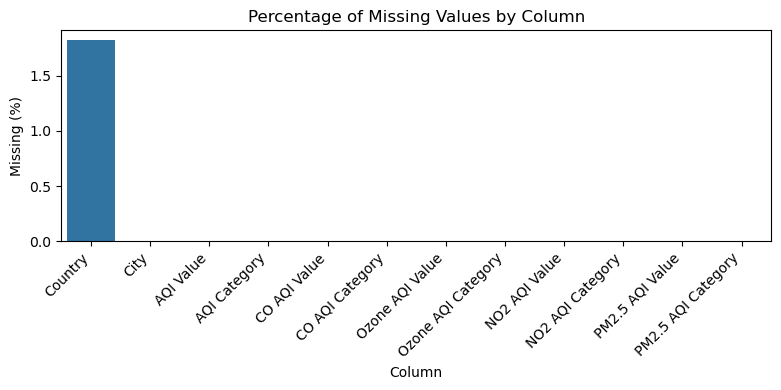

In [16]:
plt.figure(figsize=(8, 4))
sns.barplot(
    x=missing_sorted.index,
    y=missing_sorted["missing_percent"]
)
plt.title("Percentage of Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Biểu đồ cột xác nhận lại kết quả tóm tắt số liệu:

- **Country** là cột duy nhất có tỷ lệ thiếu nhìn thấy rõ.
- Các cột còn lại về cơ bản đều đầy đủ.

Xác nhận trực quan này củng cố kết luận rằng dữ liệu thiếu **có quy mô nhỏ và tập trung vào metadata địa điểm**, giúp giảm rủi ro thiên lệch do dữ liệu thiếu đối với các phân tích và mô hình tập trung vào AQI.

### 3.6.2 Heatmap dữ liệu thiếu

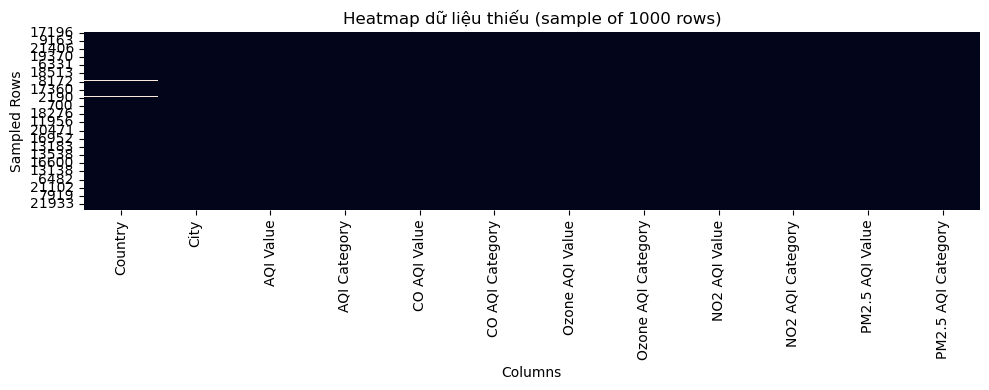

In [17]:
sample_size = min(len(df), 1000)
df_sample = df.sample(n=sample_size, random_state=0)

plt.figure(figsize=(10, 4))
sns.heatmap(df_sample.isna(), cbar=False)
plt.title(f"Heatmap dữ liệu thiếu (sample of {sample_size} rows)")
plt.xlabel("Columns")
plt.ylabel("Sampled Rows")
plt.tight_layout()
plt.show()

**Heatmap dữ liệu thiếu (mẫu 1000 dòng) cho thấy một mẫu hình thưa và rải rác:**

- Các ô thiếu gần như chỉ xuất hiện ở **Country**, và chỉ có một trường hợp ở **City**.
- Không có khối thiếu lớn hay khoảng trống có cấu trúc trải rộng qua nhiều biến AQI.

Điều này gợi ý rằng các giá trị thiếu ở Country không thể hiện sự phụ thuộc rõ ràng vào các phép đo AQI nếu chỉ quan sát trực quan. Ở giai đoạn EDA, có thể xem đây là dạng thiếu gần như ngẫu nhiên, tuy nhiên cách xử lý cuối cùng vẫn nên phù hợp với mục tiêu phân tích cụ thể.

## 3.7 Mối quan hệ & Tương quan
### 3.7.1 Ma trận tương quan cho các biến số

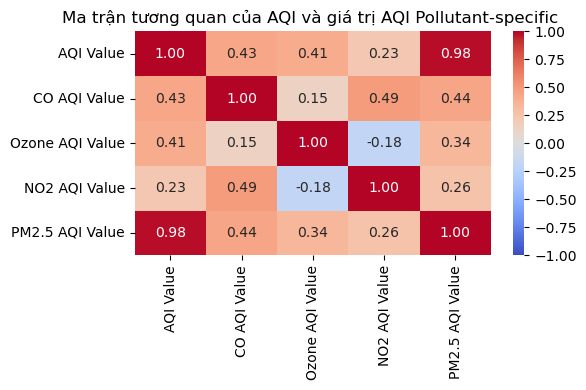

In [18]:
num_cols = [c for c in num_cols if c in df.columns]
corr_matrix = df[num_cols].corr()
corr_matrix   

plt.figure(figsize=(6, 4))
sns.heatmap(
    corr_matrix,
    annot=True,         
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
)
plt.title("Ma trận tương quan của AQI và giá trị AQI Pollutant-specific ")
plt.tight_layout()
plt.show()

Từ heatmap tương quan của  
`[AQI Value, CO AQI Value, Ozone AQI Value, NO2 AQI Value, PM2.5 AQI Value]`:

- **AQI so với các chất ô nhiễm**
  - **PM2.5 AQI Value** có tương quan dương cực mạnh với
    **AQI Value** (≈ **0.98**).  
    → AQI tổng thể gần như hoàn toàn bị chi phối bởi mức PM2.5.
  - **CO AQI Value** và **Ozone AQI Value** đều cho thấy **tương quan dương mức trung bình**
    với AQI (khoảng **0.4**).
  - **NO2 AQI Value** có **tương quan dương yếu hơn** với AQI
    (≈ **0.23**).

- **Tương quan giữa các chất ô nhiễm**
  - **CO** và **NO2** có tương quan mức trung bình (≈ **0.49**),
    gợi ý rằng chúng thường cùng tăng ở các địa điểm giống nhau.
  - **PM2.5** có tương quan mức trung bình với **CO** và **Ozone**
    (≈ **0.34–0.44**) và tương quan yếu với **NO2** (≈ **0.26**).
  - Tương quan **âm** đáng chú ý duy nhất là giữa **Ozone** và
    **NO2** (≈ **–0.18**), gợi ý rằng các đợt ozone cao có xu hướng xảy ra
    khi NO2 tương đối thấp hơn và ngược lại.

Nhìn chung, **PM2.5 nổi bật là chất ô nhiễm liên hệ mạnh nhất với
AQI tổng thể**, trong khi CO, Ozone và NO2 đóng góp vào AQI ở mức thấp hơn.

### 3.7.2 Biểu đồ phân tán giữa AQI và các chất ô nhiễm chính

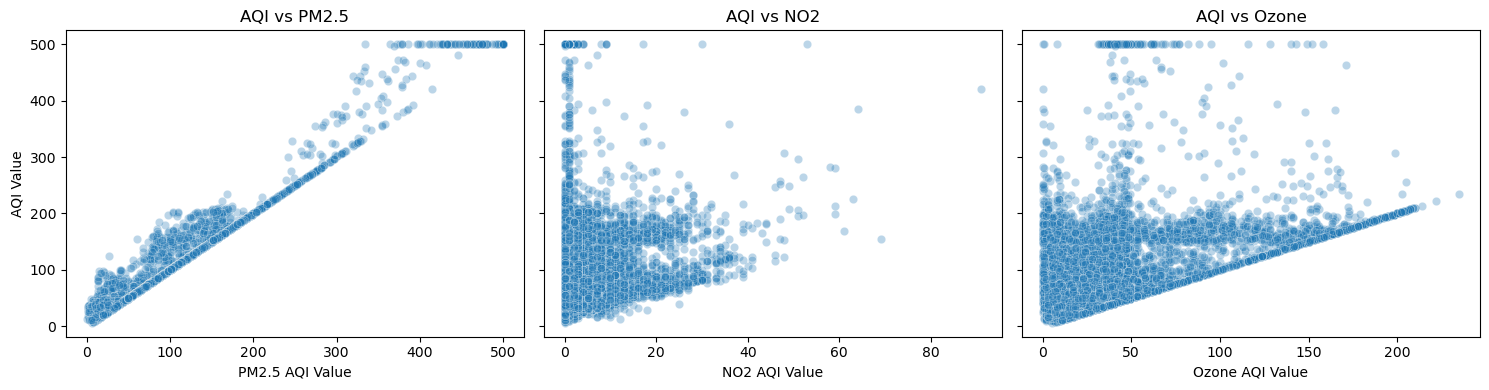

In [19]:
pairs = [
    ("PM2.5 AQI Value", "AQI Value", "AQI vs PM2.5"),
    ("NO2 AQI Value",   "AQI Value", "AQI vs NO2"),
    ("Ozone AQI Value", "AQI Value", "AQI vs Ozone"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (xcol, ycol, title) in zip(axes, pairs):
    sns.scatterplot(
        data=df,
        x=xcol,
        y=ycol,
        alpha=0.3,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)

plt.tight_layout()
plt.show()

Các biểu đồ scatter minh hoạ rõ hơn các mối quan hệ này:

- **AQI Value vs PM2.5 AQI Value**
  - Các điểm nằm gần một **xu hướng tăng chặt chẽ, gần như tuyến tính**, đặc biệt
    ở mức PM2.5 thấp đến trung bình.
  - Ở mức ô nhiễm rất cao, nhiều điểm bị chặn quanh **AQI = 500**,
    phản ánh giới hạn trên của thang AQI.
  - Điều này xác nhận rằng **AQI tăng gần như tỷ lệ thuận với PM2.5**.

- **AQI Value vs NO2 AQI Value**
  - Đám mây điểm tạo thành một **dải đứng**: một khoảng AQI rất rộng
    vẫn có thể xảy ra ngay cả khi NO2 AQI gần bằng 0.
  - Các giá trị NO2 cao hơn (ví dụ > 30) tương đối hiếm và liên quan tới
    AQI trung bình–cao, nhưng mối quan hệ phân tán hơn nhiều so với
    PM2.5.
  - → **NO2 đơn lẻ không phải là chỉ báo mạnh của AQI**.

- **AQI Value vs Ozone AQI Value**
  - Các điểm tạo dạng **quạt / tam giác**: AQI có thể thay đổi rộng ở
    cùng một mức Ozone AQI.
  - Có xu hướng tăng nhẹ nhưng độ phân tán lớn, và vẫn có nhiều điểm AQI cao
    ngay cả khi ozone ở mức trung bình.
   → Ozone có đóng góp vào các sự kiện AQI cao nhưng với **độ biến thiên đáng kể**.

Các biểu đồ này phù hợp với ma trận tương quan: PM2.5 giải thích phần lớn
phương sai của AQI, trong khi NO2 và Ozone có mối quan hệ yếu và nhiễu hơn.

### 3.7.3 Trung bình chỉ số AQI theo quốc gia

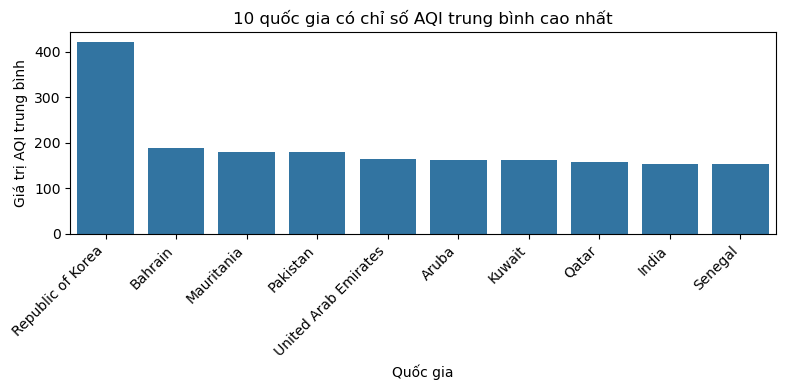

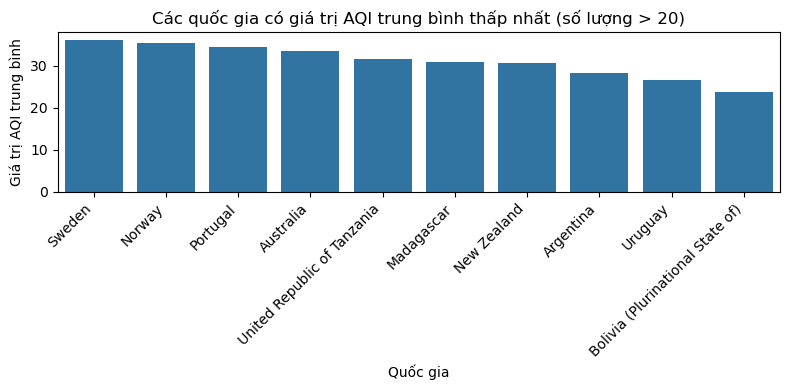

In [20]:
aqi_country_stats = (
    df.groupby("Country", dropna=False)["AQI Value"]
      .agg(["count", "mean", "median", "min", "max"])
      .sort_values("mean", ascending=False)
)
aqi_country_stats.head(15)    
aqi_country_stats.tail(15)    

top10_mean = aqi_country_stats.head(10)
plt.figure(figsize=(8, 4))
sns.barplot(x=top10_mean.index, y=top10_mean["mean"])
plt.title("10 quốc gia có chỉ số AQI trung bình cao nhất")
plt.xlabel("Quốc gia")
plt.ylabel("Giá trị AQI trung bình")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

bottom10_mean = aqi_country_stats[aqi_country_stats["count"] > 20].tail(10)
plt.figure(figsize=(8, 4))
sns.barplot(x=bottom10_mean.index, y=bottom10_mean["mean"])
plt.title("Các quốc gia có giá trị AQI trung bình thấp nhất (số lượng > 20)")
plt.xlabel("Quốc gia")
plt.ylabel("Giá trị AQI trung bình")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Sử dụng `groupby("Country")`, **top 10 quốc gia có AQI trung bình cao** bao gồm:

- **Republic of Korea** với AQI trung bình trên **400**, tách biệt rõ so với
  phần còn lại của danh sách.
- Các quốc gia khác có AQI trung bình rất cao (xấp xỉ **150–200**)
  như **Bahrain, Mauritania, Pakistan, United Arab Emirates, Aruba,
  Kuwait, Qatar, India, Senegal**.

Ở chiều ngược lại, sau khi lọc các quốc gia có ít nhất **20 bản ghi**,
**nhóm có AQI trung bình thấp nhất** được quan sát ở các quốc gia như:

- **Sweden, Norway, Portugal, Australia, United Republic of Tanzania,
  Madagascar, New Zealand, Argentina, Uruguay, Bolivia (Plurinational State of)**  
  với AQI trung bình thường nằm trong khoảng **giữa 20 đến giữa 30**.

Điều này gợi ý một sự tương phản địa lý rõ rệt:  
một số khu vực (ví dụ một phần Trung Đông và Nam Á) có xu hướng trải qua
**mức AQI cao hơn nhiều một cách hệ thống**, trong khi các quốc gia như Sweden,
Norway hay New Zealand có **chất lượng không khí ổn định và sạch hơn**.

### 3.7.4 Giá trị chất ô nhiễm trung bình theo hạng mục AQI Category

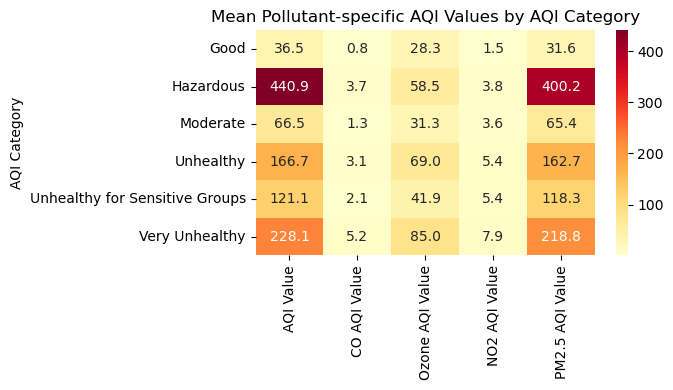

In [21]:
if "AQI Category" in df.columns:
    pollutant_means_by_cat = (
        df.groupby("AQI Category")[num_cols]
          .mean()
          .sort_index()
    )
    pollutant_means_by_cat 

    plt.figure(figsize=(7, 4))
    sns.heatmap(
        pollutant_means_by_cat,
        annot=True,
        fmt=".1f",
        cmap="YlOrRd"
    )
    plt.title("Mean Pollutant-specific AQI Values by AQI Category")
    plt.tight_layout()
    plt.show()

Heatmap giá trị trung bình của các chỉ số AQI theo **AQI Category** cho thấy một
xu hướng tăng **rất rõ ràng và đơn điệu**:

- Khi đi từ **“Good” → “Moderate” → “Unhealthy for Sensitive Groups”
  → “Unhealthy” → “Very Unhealthy” → “Hazardous”**, giá trị trung bình của **tất cả**
  các chất ô nhiễm đều tăng.
- **PM2.5 AQI Value** tăng đặc biệt mạnh:
  - ≈ **31.6** ở *Good*,
  - ≈ **65.4** ở *Moderate*,
  - ≈ **118.3** ở *Unhealthy for Sensitive Groups*,
  - ≈ **162.7** ở *Unhealthy*,
  - ≈ **218.8** ở *Very Unhealthy*,
  - ≈ **400.2** ở *Hazardous*.
- Giá trị trung bình của **AQI Value** cũng tăng theo “bậc thang” tương tự:
  - từ ≈ **36.5** (*Good*) lên ≈ **440.9** (*Hazardous*).
- CO, Ozone và NO2 cũng tăng khi chất lượng không khí xấu hơn,
  nhưng mức tăng nhỏ hơn đáng kể so với PM2.5.

Tổng hợp lại, trung bình theo từng nhóm nhãn tiếp tục củng cố các kết quả trước đó:

- **PM2.5 là yếu tố chi phối chính của chất lượng không khí kém** trong bộ dữ liệu này.
- Các mức AQI tổng cao thường đi kèm với **sự gia tăng đồng thời của nhiều chất ô nhiễm**,  
  nhưng PM2.5 có mức tăng mạnh nhất giữa điều kiện
  “Good” và “Hazardous”.

## 3.8 Những quan sát ban đầu, các vấn đề và dấu hiệu cảnh báo 

### 3.8.1 Cường độ tương quan giữa AQI và từng chất ô nhiễm

In [22]:
corr_with_aqi = corr_matrix["AQI Value"].drop("AQI Value").sort_values(ascending=False)
corr_with_aqi  

PM2.5 AQI Value    0.984327
CO AQI Value       0.430602
Ozone AQI Value    0.405310
NO2 AQI Value      0.231758
Name: AQI Value, dtype: float64

**Nhận xét**

Hệ số tương quan cho thấy **AQI Value liên hệ mạnh nhất với PM2.5 AQI Value (corr ≈ 0.98)**. 
Điều này gợi ý PM2.5 là thành phần có ảnh hưởng lớn nhất đến AQI tổng trong bộ dữ liệu.

Các chất còn lại có mức liên hệ thấp hơn:
- **CO AQI Value (≈ 0.43)** và **Ozone AQI Value (≈ 0.41)**: tương quan dương mức trung bình.
- **NO2 AQI Value (≈ 0.23)**: tương quan yếu.

Vì AQI tổng có thể được tổng hợp từ các chỉ số thành phần, mức tương quan rất cao của PM2.5 cần được ghi nhận như một dấu hiệu 
về **tính trùng thông tin/khả năng leakage** nếu sử dụng đồng thời AQI Value và PM2.5 AQI Value trong các mô hình dự đoán liên quan trực tiếp đến AQI.

### 3.8.2 phân bố AQI theo AQI Category (class balance + AQI level)

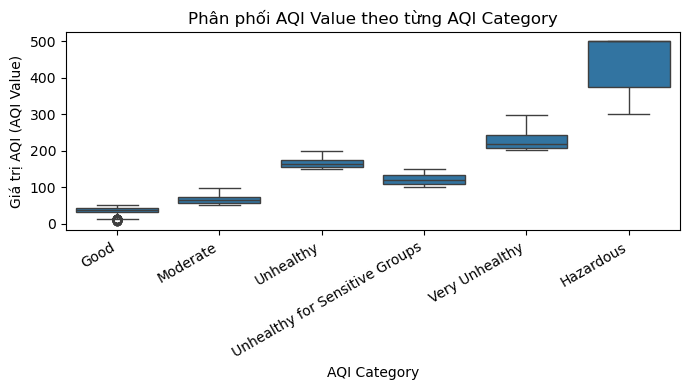

In [23]:
if "AQI Category" in df.columns:
    # Đếm số lượng mẫu trong từng nhãn AQI Category
    aqi_cat_counts = df["AQI Category"].value_counts()
    aqi_cat_counts  # số lượng mẫu của từng loại AQI

    # Thống kê mô tả AQI Value theo từng AQI Category
    aqi_by_category = df.groupby("AQI Category")["AQI Value"].describe()
    aqi_by_category  # min/25%/median/mean/75%/max cho mỗi nhóm AQI Category

    # Vẽ boxplot phân phối AQI Value theo AQI Category
    plt.figure(figsize=(7, 4))
    sns.boxplot(
        data=df,
        x="AQI Category",
        y="AQI Value",
        order=aqi_cat_counts.index
    )
    plt.title("Phân phối AQI Value theo từng AQI Category")
    plt.xlabel("AQI Category")
    plt.ylabel("Giá trị AQI (AQI Value)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


**Nhận xét**

Biểu đồ boxplot cho thấy **AQI Value tăng dần rõ rệt theo thứ tự mức độ nghiêm trọng của AQI Category**. 
Các nhóm được tách biệt khá tốt về trung vị và khoảng phân bố, phản ánh rằng nhãn phân loại đang **phù hợp với thang AQI số**.

- **Good** và **Moderate** tập trung ở mức thấp, phần lớn nằm dưới ngưỡng ~100. 
  Mức dao động nhỏ cho thấy chất lượng không khí ở hai nhóm này tương đối ổn định.

- **Unhealthy for Sensitive Groups** và **Unhealthy** dịch lên vùng cao hơn (xấp xỉ quanh 100–200), 
  với độ phân tán tăng nhẹ, thể hiện mức ô nhiễm đã bắt đầu rõ ràng hơn.

- **Very Unhealthy** nằm ở vùng ~200–300, tách biệt khá rõ so với các nhóm phía dưới.

- **Hazardous** có phân bố cao nhất và xuất hiện **hiện tượng dồn gần trần 500**, 
  phù hợp với giới hạn của thang AQI, đồng thời cho thấy đây là nhóm các trường hợp cực đoan.

Kết hợp với thống kê tần suất trước đó, **Good/Moderate chiếm đa số** trong khi 
**Very Unhealthy/Hazardous có ít mẫu**, nên nếu dùng **AQI Category** cho bài toán phân loại 
cần lưu ý mất cân bằng lớp và ưu tiên các thước đo đánh giá phù hợp (ví dụ macro-F1).

### 3.8.3 Distribution of pollutant categories (to comment on imbalance / skewness)


 -- Giá trị của AQI Category --
AQI Category
Good                              9936
Moderate                          9231
Unhealthy                         2227
Unhealthy for Sensitive Groups    1591
Very Unhealthy                     287
Hazardous                          191
Name: count, dtype: int64

 -- Giá trị của CO AQI Category --
CO AQI Category
Good                              23460
Moderate                              2
Unhealthy for Sensitive Groups        1
Name: count, dtype: int64

 -- Giá trị của Ozone AQI Category --
Ozone AQI Category
Good                              21069
Moderate                           1445
Unhealthy for Sensitive Groups      491
Unhealthy                           405
Very Unhealthy                       53
Name: count, dtype: int64

 -- Giá trị của NO2 AQI Category --
NO2 AQI Category
Good        23448
Moderate       15
Name: count, dtype: int64

 -- Giá trị của PM2.5 AQI Category --
PM2.5 AQI Category
Good                              1020

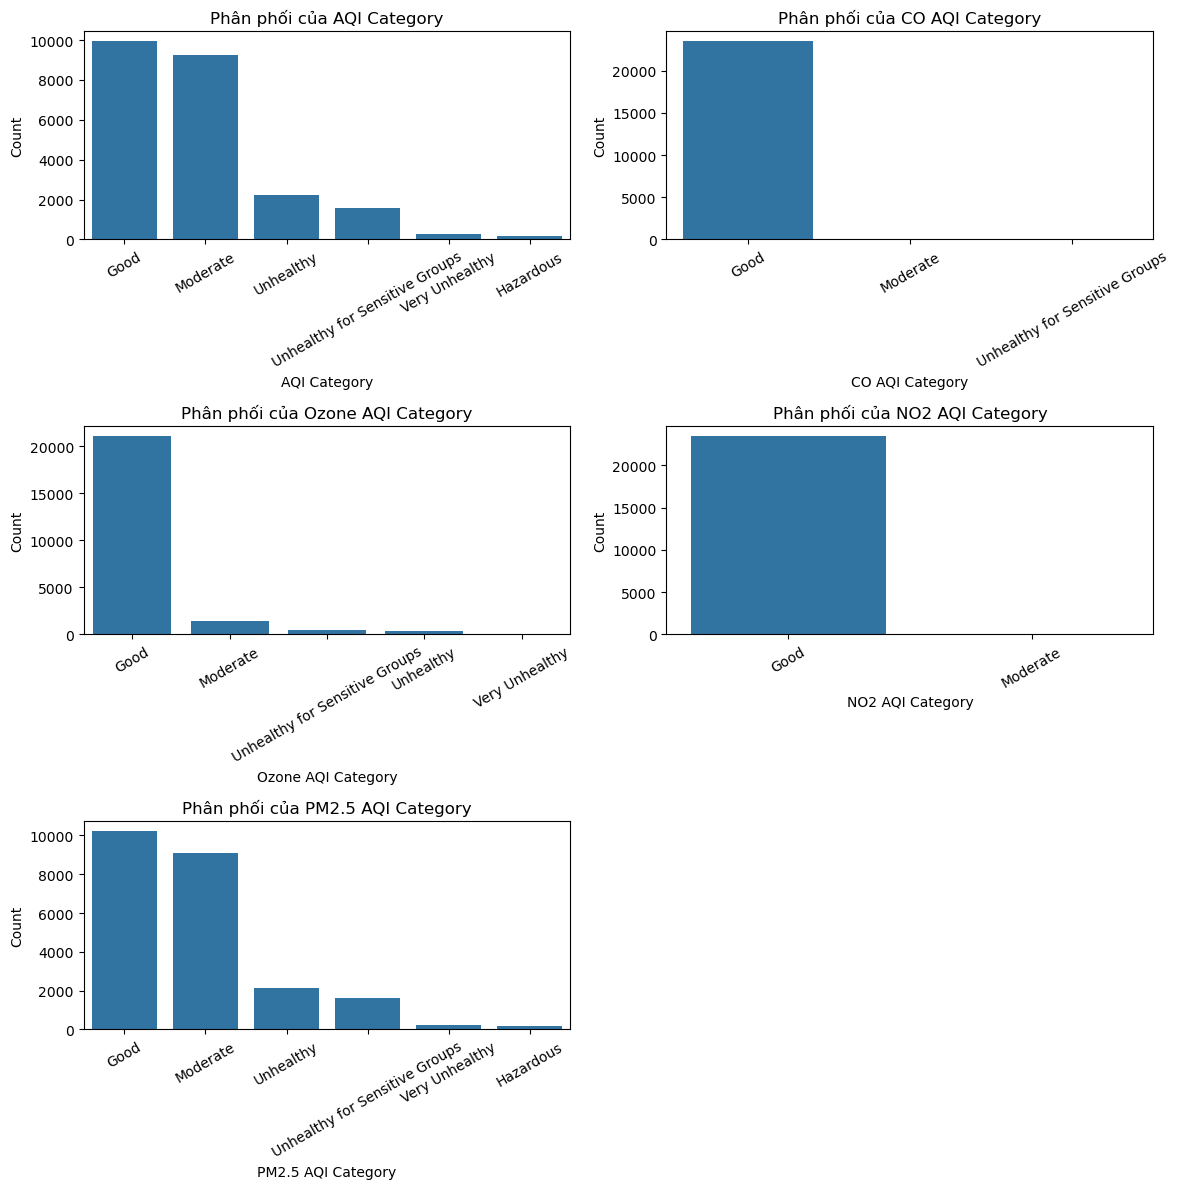

In [24]:
pollutant_cat_cols = [
    "AQI Category",
    "CO AQI Category",
    "Ozone AQI Category",
    "NO2 AQI Category",
    "PM2.5 AQI Category",
]
pollutant_cat_cols = [c for c in pollutant_cat_cols if c in df.columns]

# Tính counts để vừa in ra vừa dùng làm thứ tự hiển thị
pollutant_cat_counts = {col: df[col].value_counts() for col in pollutant_cat_cols}

# In bảng tần suất gọn gàng
for col, counts in pollutant_cat_counts.items():
    print(f"\n -- Giá trị của {col} --")
    print(counts)

# Vẽ 2x2 (mỗi hàng chia đôi)
n = len(pollutant_cat_cols)
rows = (n + 1) // 2

fig, axes = plt.subplots(rows, 2, figsize=(12, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(pollutant_cat_cols):
    counts = pollutant_cat_counts[col]
    sns.barplot(x=counts.index, y=counts.values, ax=axes[i])
    axes[i].set_title(f"Phân phối của {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=30)

# Tắt ô dư nếu có
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

- **AQI Category** có phân phối **lệch mạnh về các mức không khí sạch/trung bình**:
  - `Good`: **9,936**  
  - `Moderate`: **9,231**  
  - `Unhealthy`: **2,227**  
  - `Unhealthy for Sensitive Groups`: **1,591**  
  - `Very Unhealthy`: **287**  
  - `Hazardous`: **191**  
  → Nếu sử dụng **AQI Category** làm nhãn cho bài toán phân loại, dữ liệu sẽ gặp
  **mất cân bằng lớp rõ rệt**, đặc biệt ở hai lớp nặng nhất
  (**Very Unhealthy**, **Hazardous**) có rất ít mẫu.

- Các biến phân loại theo từng chất ô nhiễm còn **mất cân bằng mạnh hơn**:
  - **CO AQI Category**:
    - `Good`: **23,460**  
    - `Moderate`: **2**  
    - `Unhealthy for Sensitive Groups`: **1**  
    → CO gần như **luôn ở mức “Good”**, độ biến thiên rất thấp.
  - **NO2 AQI Category**:
    - `Good`: **23,448**  
    - `Moderate`: **15**  
    → NO₂ cũng **áp đảo bởi lớp “Good”**, ít giá trị cho phân tích phân loại sâu.
  - **Ozone AQI Category**:
    - `Good`: **21,069**  
    - `Moderate`: **1,445**  
    - `Unhealthy for Sensitive Groups`: **491**  
    - `Unhealthy`: **405**  
    - `Very Unhealthy`: **53**  
    → Ozone có độ trải rộng **tốt hơn CO/NO₂**, nhưng vẫn nghiêng mạnh về `Good`.
  - **PM2.5 AQI Category** (cân bằng nhất trong các chất):
    - `Good`: **10,208**  
    - `Moderate`: **9,075**  
    - `Unhealthy`: **2,129**  
    - `Unhealthy for Sensitive Groups`: **1,624**  
    - `Very Unhealthy`: **255**  
    - `Hazardous`: **172**  
    → PM2.5 có phân phối **giàu thông tin nhất** và **nhiều khả năng** là nguồn đóng góp
    lớn cho các trường hợp AQI nghiêm trọng trong bộ dữ liệu.

- Boxplot **AQI Value theo AQI Category** cho thấy **median tách biệt rõ**:
  - `Good`, `Moderate` tập trung chủ yếu trong khoảng **0–100**.
  - `Unhealthy for Sensitive Groups`, `Unhealthy` tập trung trong **100–200**.
  - `Very Unhealthy` nằm quanh **200–300**.
  - `Hazardous` tập trung sát ngưỡng trên **500**.  
  → Đây là xu hướng **đúng kỳ vọng** vì **AQI Category** được suy ra từ
  **AQI Value** theo ngưỡng chuẩn, đồng thời xác nhận rằng nhãn phân loại
  phù hợp với thang đo số.

### 3.8.4 Inspect extreme AQI values (for red flags / extreme events discussion)

In [25]:
extreme_aqi = df[df["AQI Value"] >= 400][
    [
        "Country",
        "City",
        "AQI Value",
        "AQI Category",
        "PM2.5 AQI Value",
        "PM2.5 AQI Category",
    ]
]
extreme_aqi.head(20)  

,Country,City,AQI Value,AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
276,Pakistan,Bahawalnagar,500,Hazardous,466,Hazardous
417,India,Phillaur,444,Hazardous,391,Hazardous
470,India,Rania,500,Hazardous,464,Hazardous
524,India,Gohana,500,Hazardous,500,Hazardous
598,India,Mainpuri,434,Hazardous,362,Hazardous
611,India,Gunnaur,500,Hazardous,500,Hazardous
620,Pakistan,Harunabad,500,Hazardous,443,Hazardous
644,India,Khetri,500,Hazardous,376,Hazardous
702,India,Jahangirpur,500,Hazardous,493,Hazardous
714,India,Kakrala,500,Hazardous,478,Hazardous


Tổng hợp từ phân tích thiếu dữ liệu và các phân phối đã quan sát:

- **Thiếu dữ liệu**:
  - Chỉ **Country** có tỷ lệ thiếu đáng kể (~**1.82%**), và **City** thiếu đúng **1** dòng;
    các cột AQI và AQI theo từng chất **không có** giá trị thiếu.
  - Với bước tiền xử lý:
    - Dòng thiếu **City** có thể **loại bỏ** mà không ảnh hưởng đáng kể.
    - **Country** có thể:
      - loại bỏ khi phân tích theo quốc gia, hoặc
      - thay bằng nhãn `"Unknown"` nếu chỉ dùng như biến ngữ cảnh.

- **Giá trị cực trị & outlier**:
  - Những điểm **AQI gần 500** (thường đi kèm **PM2.5 rất cao**) xuất hiện ở một số ít
    quốc gia/thành phố. Đây nhiều khả năng là **các đợt ô nhiễm cực đoan thực tế**,
    nhưng có thể gây ảnh hưởng mạnh đến độ ổn định của mô hình và metric.
  - Với bài toán hồi quy, nên cân nhắc:
    - dùng **loss/ước lượng robust**, hoặc
    - áp dụng **biến đổi/chuẩn hóa phù hợp**,
    - và kiểm tra kết quả có/không có nhóm điểm cực trị.

- **Dư thừa đặc trưng / nguy cơ leakage**:
  - Do **AQI Value** tương quan rất cao với **PM2.5 AQI Value**, việc đưa đồng thời
    cả hai vào mô hình dự đoán **AQI Value** hoặc **AQI Category** sẽ tạo
    **trùng lặp thông tin mạnh** và có nguy cơ **target leakage**.  
  → Khi AQI là mục tiêu, nên xử lý PM2.5 thận trọng (loại khỏi feature chính hoặc
  chỉ dùng trong các phân tích không dự đoán trực tiếp AQI).

- **Mất cân bằng lớp**:
  - Các lớp nặng (`Very Unhealthy`, `Hazardous`) và một số nhãn theo chất ô nhiễm
    xuất hiện rất ít.
  → Nếu xây dựng mô hình phân loại, cần:
    - **class_weight** hoặc **resampling**,
    - và dùng metric phù hợp như **macro-F1** thay vì chỉ dùng accuracy.

**Định hướng tiền xử lý tối thiểu cho bước tiếp theo**:

1. **Mã hóa biến phân loại**:
   - `Country` và các cột `* AQI Category` có thể one-hot/ordinal tùy mục tiêu.
   - **City nên dùng thận trọng** vì gần như mỗi dòng là một giá trị khác nhau;
     nên **loại khỏi feature ML** hoặc **gom nhóm theo cấp cao hơn**
     (quốc gia/khu vực) nếu cần ngữ cảnh địa lý.
2. **Chuẩn hóa/scale biến số**, nhất là khi dùng mô hình dựa trên khoảng cách
   hoặc gradient.
3. **Chọn chiến lược xử lý cực trị**:
   - giữ nguyên nhưng dùng phương pháp robust, hoặc
   - capping/transform để giảm ảnh hưởng đòn bẩy.
4. **Giải quyết mất cân bằng lớp** cho các bài toán dự đoán nhãn AQI.